In [14]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
ecoli = pd.read_csv('../ncbi_562_data.csv')
salmonella = pd.read_csv('../ncbi_590_data.csv')

C:\Users\bryan_crnqtx7\AppData\Local\Temp\ipykernel_35724\600411681.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  salmonella = pd.read_csv('../ncbi_590_data.csv')


In [15]:
ecoli = ecoli[ecoli['is_usa_based'] == 1]
ecoli['collection_year'] = pd.to_numeric(ecoli['collection_year'], errors='coerce')
ecoli = ecoli[ecoli['collection_year'] >= 2009]
salmonella = salmonella[salmonella['is_usa_based'] == 1]
salmonella['collection_year'] = pd.to_numeric(salmonella['collection_year'], errors='coerce')
salmonella = salmonella[salmonella['collection_year'] >= 2009]

In [16]:
#using ../lookup_tables/ncbi_to_nors_source_match.csv to convert isolation_source column to primary_mode_map column
primary_mode_map = pd.read_csv('../lookup_tables/ncbi_to_nors_source_match.csv')
primary_mode_map = primary_mode_map.set_index('before')['after'].to_dict()
ecoli['primary_mode_map'] = ecoli['isolation_source'].map(primary_mode_map)
salmonella['primary_mode_map'] = salmonella['isolation_source'].map(primary_mode_map)
#replace "Environmental contamination other than food/water" with "Environmental contamination"
ecoli['primary_mode_map'] = ecoli['primary_mode_map'].replace('Environmental contamination other than food/water', 'Environmental contamination')
salmonella['primary_mode_map'] = salmonella['primary_mode_map'].replace('Environmental contamination other than food/water', 'Environmental contamination')



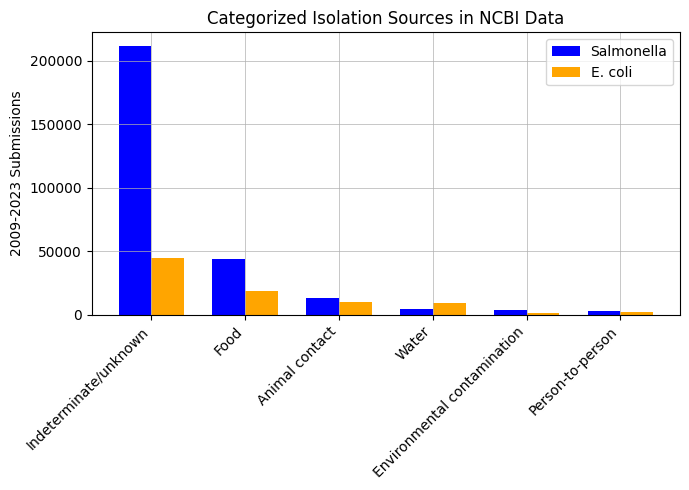

In [35]:
# Combine E. coli and Salmonella bar plots into one figure with side-by-side bars, sorted by decreasing Salmonella count
import numpy as np

top_ecoli = ecoli['primary_mode_map'].value_counts().nlargest(7)
top_salmonella = salmonella['primary_mode_map'].value_counts().nlargest(7)

# Get union of categories for consistent x-axis
categories = list(set(top_ecoli.index).union(set(top_salmonella.index)))

# Sort categories by decreasing Salmonella count
categories.sort(key=lambda cat: top_salmonella.get(cat, 0), reverse=True)

ecoli_counts = [top_ecoli.get(cat, 0) for cat in categories]
salmonella_counts = [top_salmonella.get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(7, 5))
salmonella_bars = plt.bar(x - width/2, salmonella_counts, width, label='Salmonella', color='blue', align='center')
ecoli_bars = plt.bar(x + width/2, ecoli_counts, width, label='E. coli', color='orange', align='center')

plt.title('Categorized Isolation Sources in NCBI Data')
plt.xlabel('')
plt.grid(axis='both', linewidth=0.5)
plt.ylabel('2009-2023 Submissions')
plt.xticks(x, categories, rotation=45, ha='right')
plt.yticks([200000, 150000, 100000, 50000, 0])
plt.legend(handles=[salmonella_bars, ecoli_bars])
plt.tight_layout()
plt.savefig('../outputs/ecoli_salmonella_primary_mode_map.tiff', dpi=400)
plt.show()

Made changes.

The code in cell 4 now combines the E. coli and Salmonella bar plots into a single figure with side-by-side bars for each category. The x-axis shows the union of the top 7 categories from both datasets, and the bars are color-coded and labeled for each organism. The figure is saved as `ecoli_salmonella_primary_mode_map.tiff` in the outputs folder. Let me know if you want further customization!